# Исследовательский анализ рынка заведений общественного питания Москвы

- Автор: Мельников Даниил
- Дата: 16.02.2026 г.

**Контекст:** Фонд Shut Up And Take My Money планирует открыть заведение общественного питание в Москве. Формат заведения на данный момент не определен. 

**Цель анализа:** Проанализировать рынок заведений общественного питания на основе открытых данных и предоставить Заказчику рекомендации по формату заведения.

**Задачи:**
- ознакомиться с открытыми данными;
- провести предобработку данных;
- изучить категории заведений, их территориальное расположение, принадлежность к сети, вместимость, рейтинг, размер среднего чека;
- проанализировать топ-15 сетевых заведений в Москве;

**Описание данных:**

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    0 — заведение не является сетевым;
    1 — заведение является сетевым.
- seats — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    «Средний счёт: 1000–1500 ₽»;
    «Цена чашки капучино: 130–220 ₽»;
    «Цена бокала пива: 400–600 ₽».
    и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

# Содержание  
[1. Загрузка данных и знакомство с ними](#загрузка-данных-и-знакомство-с-ними)  
[2. Предобработка данных](#предобработка-данных)  
&nbsp;&nbsp;[2.2. Предобработка пропущенных значений](#предобработка-пропущенных-значений)  
&nbsp;&nbsp;[2.3. Предобработка дубликатов](#предобработка-дубликатов)  
&nbsp;&nbsp;[2.4. Создаем новый столбец](#создаем-новый-столбец)  
[3. Промежуточный вывод](#промежуточный-вывод)  
[4. Исследовательский анализ данных](#исследовательский-анализ-данных)  
[5. Итоговый вывод и рекомендации](#итоговый-вывод-и-рекомендации)

## Загрузка данных и знакомство с ними

In [1]:
# выгружаем библиотеки, необходимые для анализа и визуализации результатов
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# выгружаем библиотеку для рассчета коэффициента корреляции
from phik import phik_matrix

In [2]:
# выгружаем датасет с информацией о ресторане
rest_info = pd.read_csv('/datasets/rest_info.csv')

rest_info.info()
rest_info.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Файл `rest_info.csv` содержит 8406 строк и 9 столбцов. Пропуски присутствуют в столбцах `hours` и `seats`. Информация о посадочных местах хранится в `float64`, логичнее ее привести к `int64`. В остальном данные соответсвуют описанию, а их типы верны.

In [3]:
# выгружаем датасет с информацией о ценах
rest_price = pd.read_csv('/datasets/rest_price.csv')

rest_price.info()
rest_price.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


Файл `rest_price.csv` содержит 4058 строк и 5 столбцов. Кажется целесообразным привести значения в столбцах `middle_avg_bill` и `middle_coffee_cup` к целочисленному формату. Все столбцы, кроме `id` содержат пропуски, их будет необходимо исследовать более детально. Для удобства объединим датасеты в один датафрейм по общему столбцу `id` (уникальный идентификатор заведения).

In [4]:
# объединяем датасеты в общий датафрейм
df = rest_info.merge(rest_price, on='id', how='left')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


После объединения получаем 8406 строки и 13 столбцов в датафрейме. Для начала приведем данные к соответствующему формату, а затем проведем предобработку пропусков.

## Предобработка данных

### Оптимизация типов данных

In [5]:
# приводим столбцы seats, middle_avg_bill и middle_coffee_cup к адекватному типу данных
df[['seats', 'middle_avg_bill', 'middle_coffee_cup']] = df[['seats', 'middle_avg_bill', 'middle_coffee_cup']].astype('Int64')
df[['seats', 'middle_avg_bill', 'middle_coffee_cup']].dtypes

seats                Int64
middle_avg_bill      Int64
middle_coffee_cup    Int64
dtype: object

### Предобработка пропущенных значений

In [6]:
# выводим информацию о пропусках в абсолютных и относительных значениях
display(df.isna().sum())
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

middle_coffee_cup    93.635498
middle_avg_bill      62.538663
price                60.563883
avg_bill             54.603854
seats                42.957411
hours                 6.376398
district              0.000000
category              0.000000
name                  0.000000
id                    0.000000
address               0.000000
chain                 0.000000
rating                0.000000
dtype: float64

In [7]:
# изучим пропуски в столбце hours
missing_rows = df[df['hours'].isna()]
missing_rows

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
38,3746fe879e5b43629512095693ce4113,Ижора,булочная,"Москва, Ижорский проезд, 5А",Северный административный округ,NaN,4.4,0,<NA>,NaN,NaN,<NA>,<NA>
40,e5f4ff8c7196472eac2c980fc6b2e9b2,Кафе,кафе,"Москва, Ижорская улица, 18, стр. 1",Северный административный округ,NaN,3.7,0,<NA>,NaN,NaN,<NA>,<NA>
44,0cb57ea286804a0fbff91ae2cc868d48,Кафетерий,кафе,"Москва, Ангарская улица, 24А",Северный административный округ,NaN,3.8,1,8,NaN,NaN,<NA>,<NA>
56,2b2b60640efb494b8ed4aa3b1313f1cd,Рыба из тандыра,быстрое питание,"Москва, Коровинское шоссе, 46, стр. 5",Северный административный округ,NaN,1.5,0,<NA>,NaN,NaN,<NA>,<NA>
108,a9ad4bd7e15c4b8cb6295c745e5a11c1,Кафе,"бар,паб","Москва, МКАД, 82-й километр, вл18",Северо-Восточный административный округ,NaN,4.2,0,<NA>,NaN,NaN,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8236,4c48d06135d744a5a9d05e56d48d3818,1у,кафе,"Москва, Нагатинская набережная, 40/1к1",Южный административный округ,NaN,3.4,0,<NA>,NaN,NaN,<NA>,<NA>
8375,f2cca1ec4a9348a686f0b9e86dba4e7b,Улица Гурьянова 55,кафе,"Москва, улица Гурьянова, 55",Юго-Восточный административный округ,NaN,4.5,0,<NA>,NaN,NaN,<NA>,<NA>
8378,7cbd1c883e8a4b8e93ef33dfc4cc1c14,Восточно-грузинская кухня,быстрое питание,"Москва, Зеленодольская улица, 32, корп. 3",Юго-Восточный административный округ,NaN,4.3,0,120,NaN,NaN,<NA>,<NA>
8381,ba0d8f9430004985a42e2a5cd6554b9e,Аэлита,кафе,"Москва, Ферганская улица, 8, корп. 2, стр. 1",Юго-Восточный административный округ,NaN,3.8,0,30,NaN,NaN,<NA>,<NA>


Видим, что в данных строках отсутствует информация по многим столбцам, а также наблюдается рейтинг ниже среднего, поэтому принимаем решения удалить строки с пропусками в столбце `hours`. 

In [8]:
# удаляем строки с пропусками в столбце hours
df = df.dropna(subset=['hours'])
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                   0
rating                  0
chain                   0
seats                3375
price                4560
avg_bill             4062
middle_avg_bill      4727
middle_coffee_cup    7336
dtype: int64

In [9]:
# проверяем пропуски в столбце seats
missing_rows = df[df['seats'].isna()]
missing_rows

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,NaN,NaN,<NA>,<NA>
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,NaN,Цена чашки капучино:155–185 ₽,<NA>,170
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,<NA>,средние,NaN,<NA>,<NA>
11,53ac103717c142f29907080db1f0ce58,Шашлык Шефф,кафе,"Москва, улица Маршала Федоренко, 10с1",Северный административный округ,"ежедневно, 10:00–21:00",4.9,0,<NA>,NaN,NaN,<NA>,<NA>
12,9384a51a4b2749759234df689b3a4857,Заправка,кафе,"Москва, МКАД, 80-й километр, 1",Северный административный округ,вт-сб 09:00–18:00,4.3,0,<NA>,средние,Средний счёт:330 ₽,330,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8386,9499032946a443b890635147cdebb9a6,Греки Здесь,ресторан,"Москва, улица Авиаконструктора Миля, 3А",Юго-Восточный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.1,0,<NA>,NaN,NaN,<NA>,<NA>
8387,962800540173458486f3c465437c2d8b,Pab&burg,"бар,паб","Москва, улица Михайлова, 22, корп. 4",Юго-Восточный административный округ,"ежедневно, 12:00–21:30",4.2,0,<NA>,средние,Цена бокала пива:от 140 ₽,<NA>,<NA>
8389,3e5d9167d59248a69e6f3d6a0749d38c,Assa,ресторан,"Москва, улица Авиаконструктора Миля, 3А",Юго-Восточный административный округ,"пн-чт 09:00–22:00; пт,сб 09:00–23:00; вс 09:00...",4.9,0,<NA>,NaN,NaN,<NA>,<NA>
8392,c55cb77b463b489491e703b8a94f286a,Касабланка,кафе,"Москва, Большая Косинская улица, 27",Восточный административный округ,пн-чт 08:00–17:00; пт 08:00–16:00,3.3,0,<NA>,NaN,NaN,<NA>,<NA>


Данный столбец содержит более 40% пропусков, но предварительно не будет являться ключевым для проведения анализа. Чтобы не исказить данные, принимаем решение оставить столбец.

Столбцы `middle_avg_bill` и `middle_coffee_cup`напрямую зависят от столбца `avg_bill`. 
Случаи, в которых пропуски есть в `avg_bill`, оставим как есть, дабы не исказить данные.
Для случаев, в которых есть значения в `avg_bill`, но нет или `middle_avg_bil`, или в `middle_coffee_cup`, найдем или медиану (если в `avg_bill` указан диапазон двух значений), или выведем то же самое значение из столбца `avg_bill` (если в `avg_bill` указано одно число).

In [10]:
# пишем цикл для заполнения пропущенных значений
for i in range(len(df)): # поиск по всем строкам
    if pd.isna(df.iloc[i]['avg_bill']): # оставляем пропуски в avg_bill
        continue
    text = str(df.iloc[i]['avg_bill']) # приводим данные к строке
    
    # ищем все числа в тексте 
    numbers = []
    current_number = ''
    
    for char in text:
        if char.isdigit() or char == '.':
            current_number += char
        elif current_number:
            try:
                numbers.append(float(current_number))
                current_number = ''
            except:
                current_number = ''
    
    # проверяем последнее число, если есть
    if current_number:
        try:
            numbers.append(float(current_number))
        except:
            pass
    
    if not numbers:
        continue   
     
    # Рассчитываем значение
    if len(numbers) == 2:
        value = (numbers[0] + numbers[1]) / 2  # медиана двух чисел
    else:
        value = numbers[0]  # единственное число   

    # Заполняем нужный столбец
    if text.startswith('Средний счёт') and pd.isna(df.iloc[i]['middle_avg_bill']):
        df.iloc[i, df.columns.get_loc('middle_avg_bill')] = value
    
    elif text.startswith('Цена одной чашки капучино') and pd.isna(df.iloc[i]['middle_coffee_cup']):
        df.iloc[i, df.columns.get_loc('middle_coffee_cup')] = value

df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                   0
rating                  0
chain                   0
seats                3375
price                4560
avg_bill             4062
middle_avg_bill      4727
middle_coffee_cup    7336
dtype: int64

### Предобработка дубликатов

In [11]:
# выведем уникальные значения категориальных столбцов
for column in ['name', 'category', 'address', 'district', 'hours', 'rating', 'chain', 'seats', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце name:
['#КешбэкКафе' '+39 Pizzeria Mozzarella bar' '1 Этаж' ... 'Ясно' 'Яуза'
 'ночной Баку']

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце address:
['Москва, 1-й Автозаводский проезд, 5'
 'Москва, 1-й Балтийский переулок, 3/25'
 'Москва, 1-й Варшавский проезд, 1Ас9' ...
 'Москва, шоссе Энтузиастов, 66/1' 'Москва, шоссе Энтузиастов, 86, стр. 6'
 'Москва, шоссе Энтузиастов, 86А, корп. 3']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце hours:
['Нет информации'
 'вт 08:30–17:00; ср,чт 1

Чтобы проверить наличие дубликатов, приведем названия заведений к нижнему регистру. Адреса оставим без изменений, т.к. по одному адресу могут находиться сразу несколько заведений.

In [12]:
# приводим названия заведений и адресов к нижнему регистру
df['name'] = df['name'].str.lower()
df['address'] = df['address'].str.lower()

display(df['name'].unique())
df['address'].unique()

array(['wowфли', 'четыре комнаты', 'хазри', ..., 'миславнес', 'самовар',
       'kebab time'], shape=(5219,), dtype=object)

array(['москва, улица дыбенко, 7/1', 'москва, улица дыбенко, 36, корп. 1',
       'москва, клязьминская улица, 15', ...,
       'москва, улица лобачевского, 52, корп. 1',
       'москва, болотниковская улица, 52, корп. 2',
       'москва, чонгарский бульвар, 26а, корп. 1'],
      shape=(5459,), dtype=object)

In [13]:
# находим явные дубликаты
duplicated_mask = df.duplicated(subset=['id', 'name', 'category', 'address', 'district', 'rating', 'chain'], keep='first')
duplicates = df[duplicated_mask]
df.duplicated().sum()

np.int64(0)

Явные дубликаты отсутствуют.

In [14]:
# выводим неявные дубликаты
implicit_duplicates = df[df.duplicated(subset=['name', 'address'], keep=False)]
implicit_duplicates

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,<NA>,<NA>
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,<NA>,<NA>
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,<NA>,<NA>
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,<NA>,<NA>
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,<NA>,<NA>
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,<NA>,<NA>


Дубликаты кафе "кафе", ресторан "more poke" и паб раковарня "клешни и хвосты" различаются временем работы. Предположим, что оно в определенный момент изменилось, и заведение было заново добавлено в датасет. У раковарни также, предположительно, сменился формат заведения, т.к. мы наблюдаем разичие в категориях (ресторан и паб). Принимаем решение удалить дубликаты и оставить последние вхождения.

In [15]:
# оставляем последние вхождения неявных дубликатов
implicit_duplicates = df[df.duplicated(subset=['name', 'address'], keep='last')]

### Создаем новый столбец

In [16]:
# создаем функцию для подсчета круглосуточных заведений
def create_24_7(x):
    if 'круглосуточно' in x:
        return 1
    else:
        return 0
        
# создаем столбец
df['is_24_7'] = df['hours'].apply(create_24_7)
df['is_24_7'].tail()

8401    0
8402    0
8403    1
8404    1
8405    1
Name: is_24_7, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7870 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7870 non-null   object 
 1   name               7870 non-null   object 
 2   category           7870 non-null   object 
 3   address            7870 non-null   object 
 4   district           7870 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             7870 non-null   float64
 7   chain              7870 non-null   int64  
 8   seats              4495 non-null   Int64  
 9   price              3310 non-null   object 
 10  avg_bill           3808 non-null   object 
 11  middle_avg_bill    3143 non-null   Int64  
 12  middle_coffee_cup  534 non-null    Int64  
 13  is_24_7            7870 non-null   int64  
dtypes: Int64(3), float64(1), int64(2), object(8)
memory usage: 945.3+ KB


## Промежуточный вывод

По итогу ознакомления с данными и их предобработкой, сформировался датафрейм из 7870 строк и 14 столбцов. Именно с этими данными мы будем работать, анализируя актуальный рынок заведений общественного питания в Москве.

## Исследовательский анализ данных

<function matplotlib.pyplot.show(close=None, block=None)>

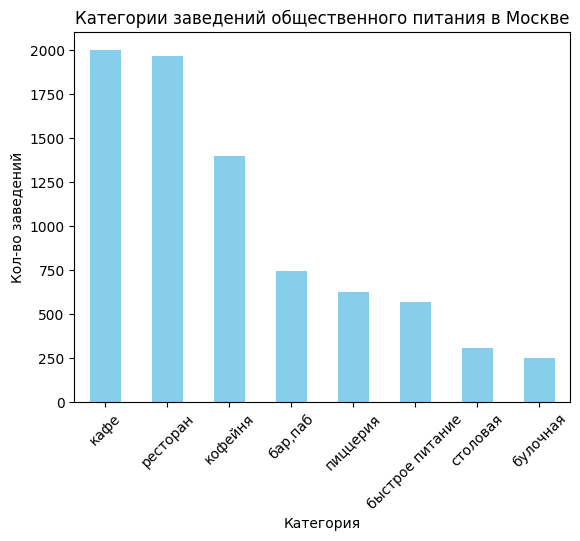

In [18]:
# рассмотрим популярность заведений по категориям
df['category'].value_counts().plot(kind='bar',
                                   title='Категории заведений общественного питания в Москве',
                                   legend=False,
                                   ylabel='Кол-во заведений',
                                   xlabel='Категория',
                                   rot=45,
                                   color='skyblue')
plt.show

В Москве больше всего кафе и ресторанов, а булочные и столовые представлены наименьшим числом.

<function matplotlib.pyplot.show(close=None, block=None)>

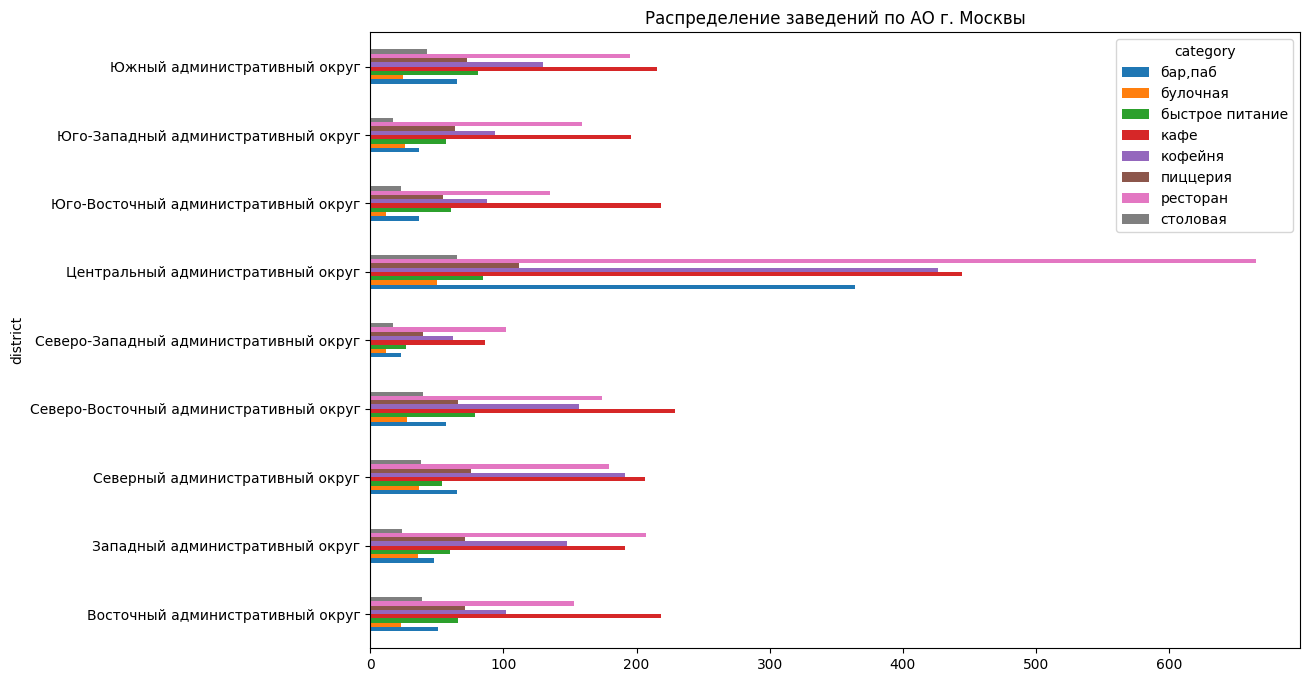

In [19]:
# рассмотрим, как заведения распределны по административным округам.
df_unstack = df.groupby('district')['category'].value_counts().unstack(fill_value=0)
df_unstack.plot(kind='barh',
                title='Распределение заведений по АО г. Москвы',
                figsize=(12, 8))
plt.show

Из графика видно, что наибольшее кол-во заведений располагаются в Центральном административном округе. Рассмотрим его отдельно, и то, как распределились заведения в нем.

<function matplotlib.pyplot.show(close=None, block=None)>

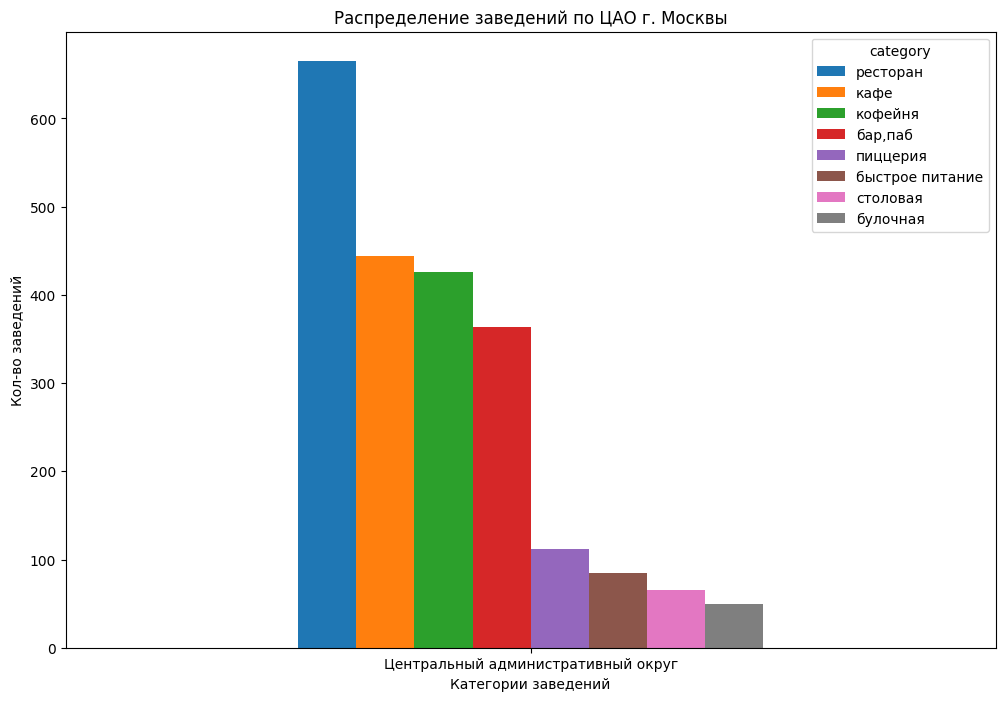

In [20]:
# изучаем распределение заведений в ЦАО г. Москвы

df_unstack = df[df['district'] == 'Центральный административный округ'].groupby('district')['category'].value_counts().unstack(fill_value=0)
df_unstack_sorted = df_unstack[df_unstack.sum().sort_values(ascending=False).index]
df_unstack_sorted.plot(kind='bar',
                title='Распределение заведений по ЦАО г. Москвы',
                ylabel='Кол-во заведений',
                xlabel='Категории заведений',
                rot=0,
                figsize=(12, 8))
plt.show

В ЦАО наиболее широко представлены рестораны, также популярны кафе, кофейни и бары. А вот булочных, фастфудов, пиццерий и столовых наоборот очень мало.

<Axes: title={'center': 'Является ли заведение сетевым'}, xlabel='chain', ylabel='Кол-во заведений'>

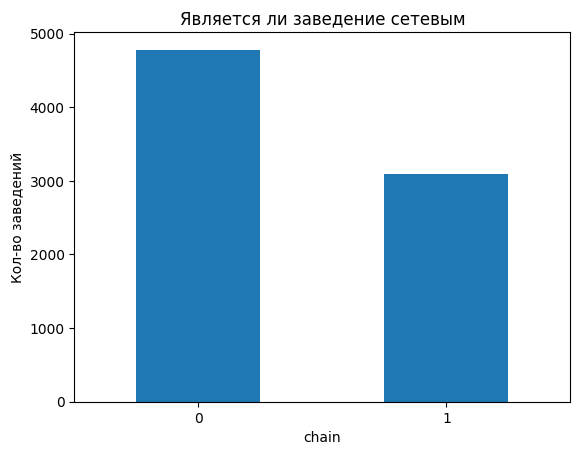

In [21]:
# изучим соотношение сетевых заведений к несетевым
df['chain'].value_counts().plot(
    kind='bar',
    title='Является ли заведение сетевым',
    ylabel='Кол-во заведений',
    rot=0)

Из графика выше следует, что в Москве преобладают несетевые заведения. Сети общественного питания рассмотрим более подробно.

<Axes: title={'center': 'Кол-во сетевых заведений по категориям'}, xlabel='Кол-во заведений', ylabel='Категории'>

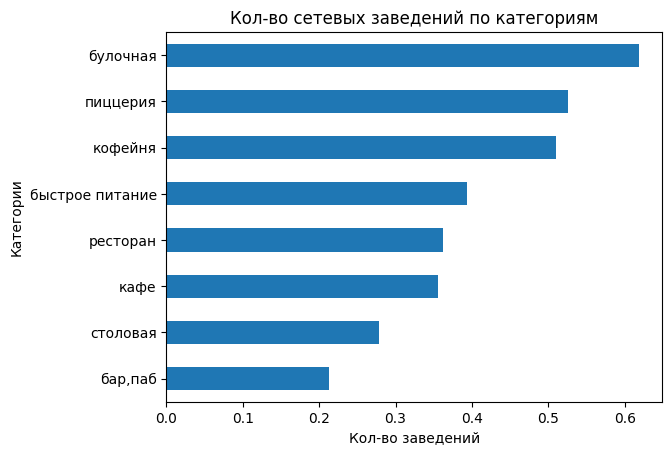

In [22]:
# рассмотрим какие категории заведений чаще всего являются сетевыми
chain_ratio = df.groupby('category')['chain'].mean().sort_values()
chain_ratio.plot(
    kind='barh',
    title='Кол-во сетевых заведений по категориям',
    legend=False,
    ylabel='Категории',
    xlabel='Кол-во заведений',
    rot=0)

Видим, что, как правило, сетевыми являются кафе, рестораны и кофейни.

Text(0.5, 0, 'Кол-во посадочных мест')

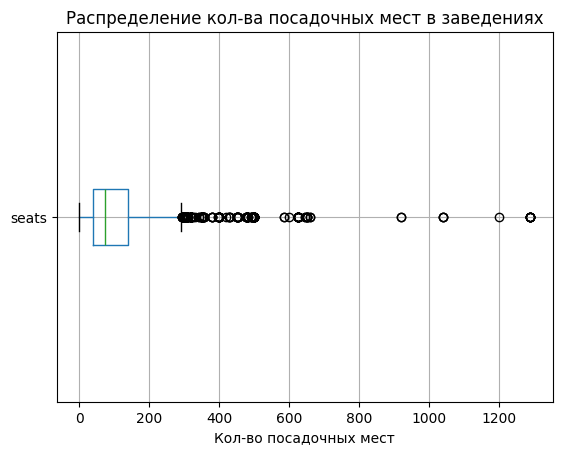

In [23]:
# изучим кол-во посадочных мест в заведении
boxplot = df.boxplot(column='seats',
                     vert=False)
boxplot.set_title('Распределение кол-ва посадочных мест в заведениях')
boxplot.set_xlabel('Кол-во посадочных мест')     

На данном графике наблюдаем большое кол-во выбросов справа с аномально большим количеством посадочных мест. Рассмотрим распределение посадочных мест по категориям.

<Axes: title={'center': 'Среднее кол-во посадочных мест для каждой категории'}, ylabel='category'>

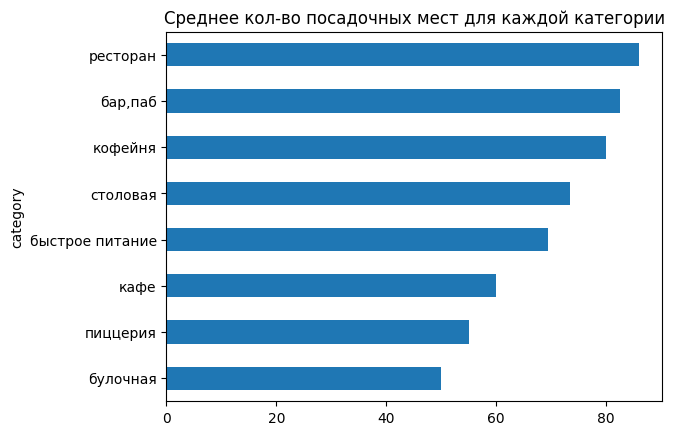

In [24]:
# рассмотрим типичное кол-во посадочных мест по категориям
df.groupby('category')['seats'].median().sort_values().plot(kind='barh', title='Среднее кол-во посадочных мест для каждой категории', rot=0)

Видим, что в среднем кол-во посадочных мест в г. Москве составляет 50-80 мест.

<Axes: title={'center': 'Средний рейтинг заведений по категориям'}, ylabel='category'>

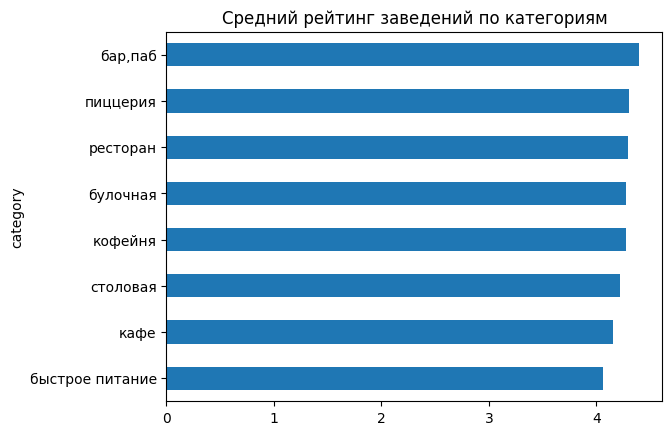

In [25]:
# анализируем средний рейтинг
avg_rating_by_category = df.groupby('category')['rating'].mean().sort_values()
avg_rating_by_category.plot(kind='barh',
                            title='Средний рейтинг заведений по категориям')

Из данного графика следует, что независимо от категории заведения в Москве имеют в среднем высокие оценки (4.0+). Рассмотрим, с какими данными рейтинг наиболее тесно связан.

<Axes: title={'center': 'Связь рейтинга и категории заведения'}, xlabel='rating', ylabel='category'>

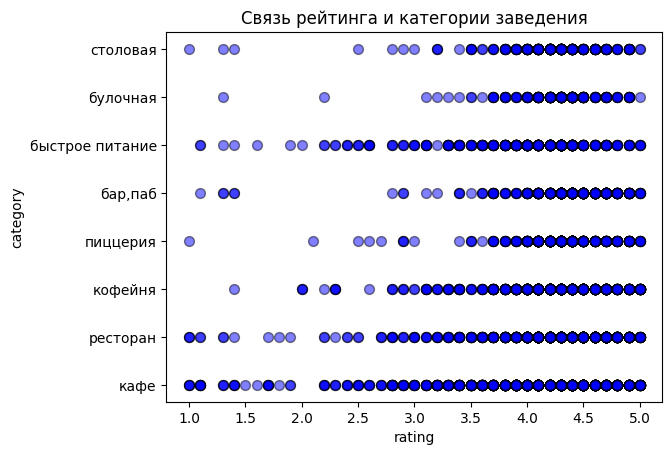

In [26]:
# строим матрицу корреляции рейтинга с категорией заведения
df.plot(kind='scatter',
        x='rating',
        y='category',
        alpha=0.5,
        color='blue',
        edgecolor='black',
        s=50,
        title='Связь рейтинга и категории заведения')

<Axes: title={'center': 'Связь рейтинга с местоположением заведения'}, xlabel='rating', ylabel='district'>

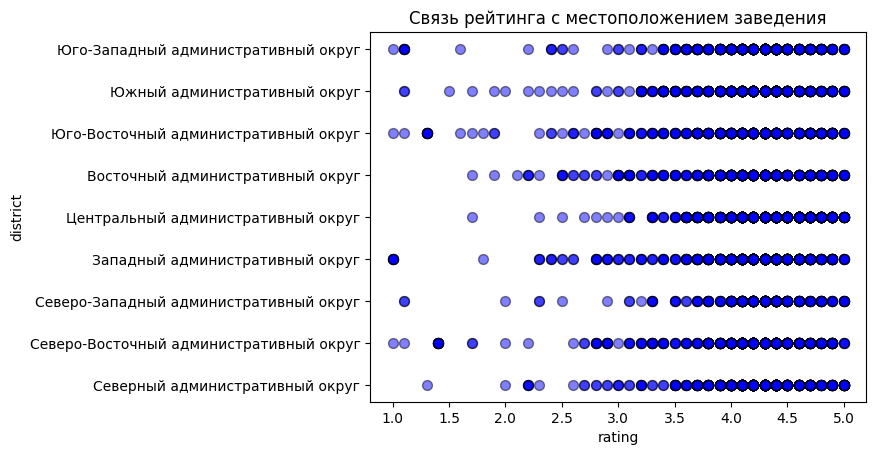

In [27]:
# строим матрицу корреляции рейтинга с местоположением заведения
df.plot(kind='scatter',
        x='rating',
        y='district',
        alpha=0.5,
        color='blue',
        edgecolor='black',
        s=50,
        title='Связь рейтинга с местоположением заведения')

<Axes: title={'center': 'Связь рейтинга со статусом сетевого заведения'}, xlabel='rating', ylabel='chain'>

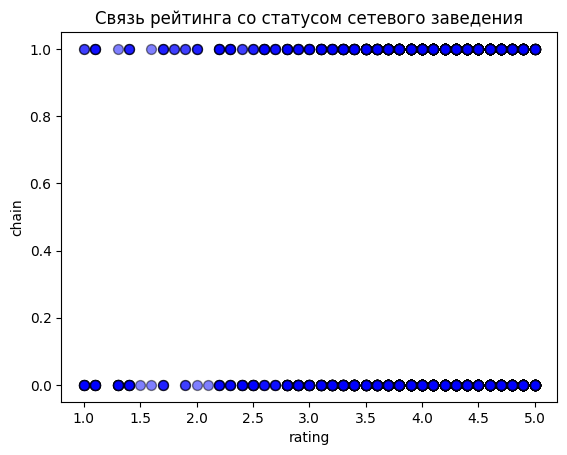

In [28]:
# строим матрицу корреляции рейтинга со статусом сетевого заведения
df.plot(kind='scatter',
        x='rating',
        y='chain',
        alpha=0.5,
        color='blue',
        edgecolor='black',
        s=50,
        title='Связь рейтинга со статусом сетевого заведения')

<Axes: title={'center': 'Связь рейтинга с кол-вом посадочных мест'}, xlabel='rating', ylabel='seats'>

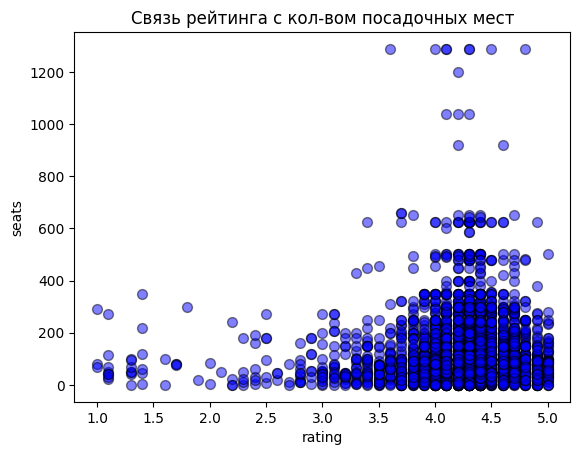

In [29]:
# строим матрицу корреляции рейтинга с кол-вом посадочных мест
df.plot(kind='scatter',
        x='rating',
        y='seats',
        alpha=0.5,
        color='blue',
        edgecolor='black',
        s=50,
        title='Связь рейтинга с кол-вом посадочных мест')

<Axes: title={'center': 'Связь рейтинга с круглосуточным режимом заведения'}, xlabel='rating', ylabel='is_24_7'>

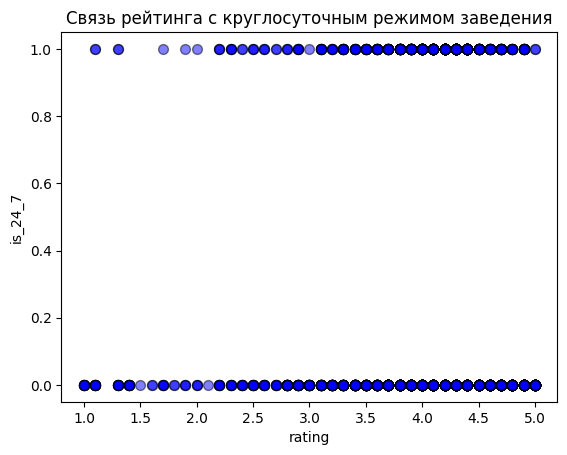

In [30]:
# строим матрицу корреляции рейтинга с режимом работы заведения
df.plot(kind='scatter',
        x='rating',
        y='is_24_7',
        alpha=0.5,
        color='blue',
        edgecolor='black',
        s=50,
        title='Связь рейтинга с круглосуточным режимом заведения')

<Axes: title={'center': 'Топ-15 популярных сетей в Москве'}, xlabel='name', ylabel='count'>

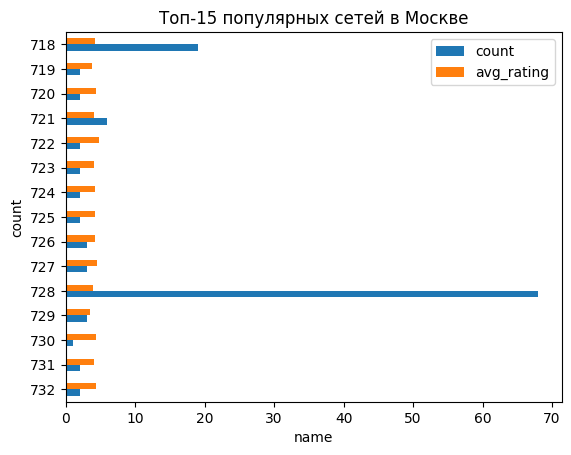

In [31]:
# рассмотрим популярные сетевые заведения
df_chain = df[df['chain'] == 1]
df_chain_group = df_chain.groupby('name').agg(
    count=('name', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
top_15 = df_chain_group.sort_values('name', ascending=False).head(15)
top_15.plot(kind='barh', title='Топ-15 популярных сетей в Москве', xlabel='name', ylabel='count')

<Axes: ylabel='district'>

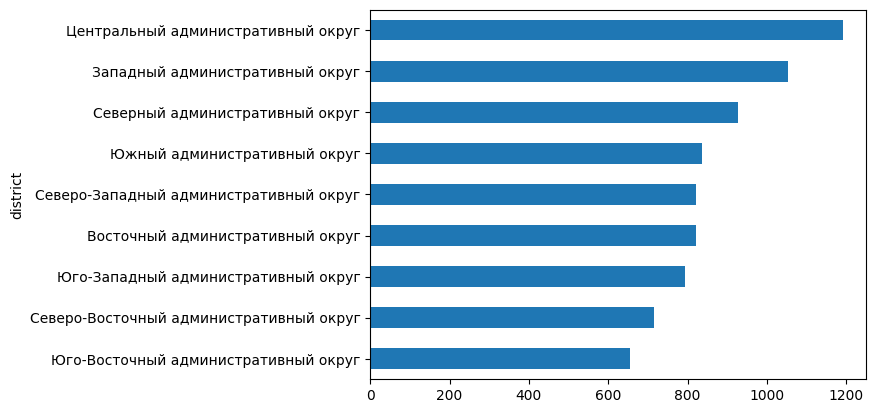

In [32]:
# рассмотрим размер среднего чека по округам
df_plot = df.groupby('district')['middle_avg_bill'].mean().sort_values()
df_plot.plot(kind='barh')

Из графика выше следуюет, что самый высокий средний чек - в ЦАО, далее чем дальше от цента, тем ниже ценник.

## Итоговый вывод и рекомендации

Итак, был проведенн исследовательский анализ рынка заведений общественного питания. Исходя из полученной информации, видно, что в Москве превалируют форматы кафе и ресторанов. Наиболее густо заполненным является Центральный административный округ, там же и самый высокий средний чек. Более 50% всех заведений в городе рассчитаны на 50-80 посадочных мест, однако присутствуют и более вместительные рестораны. Уровень заведения, однако, от его категории в среднем не зависит.
Рекомедовано рассмотреть либо формат кафе или ресторана в ЦАО, как наиболее популярный формат заведения. Либо выбрать прилегающее к ЦАО расположение (соседние округа) в формате кафе или бара.